# Homework Submission - Stage 08 EDA

This completed notebook uses the starter's seeded synthetic dataset to demonstrate the full EDA flow.


In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

Matplotlib is building the font cache; this may take a moment.


,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[us]
 1   region        160 non-null    str           
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 8.3 KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [4]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.

Categorical profile: region


,count,proportion
region,,
West,47,0.29375
East,42,0.26250
South,36,0.22500
North,35,0.21875


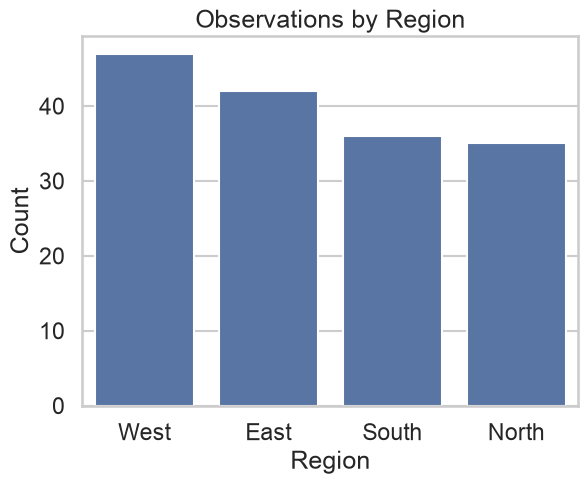

In [5]:
categorical_columns = df.select_dtypes(
    include=['object', 'category', 'string']
).columns

for column in categorical_columns:
    profile = pd.DataFrame({
        'count': df[column].value_counts(dropna=False),
        'proportion': df[column].value_counts(dropna=False, normalize=True),
    })
    print(f'Categorical profile: {column}')
    display(profile)

sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.title('Observations by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()


## 3) Distributions — two worked examples below; add at least one more

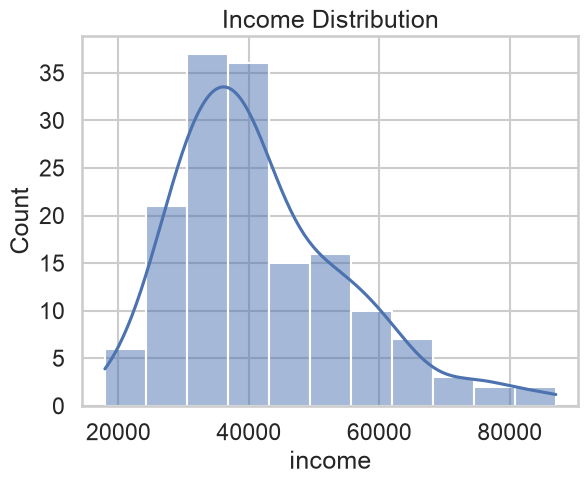

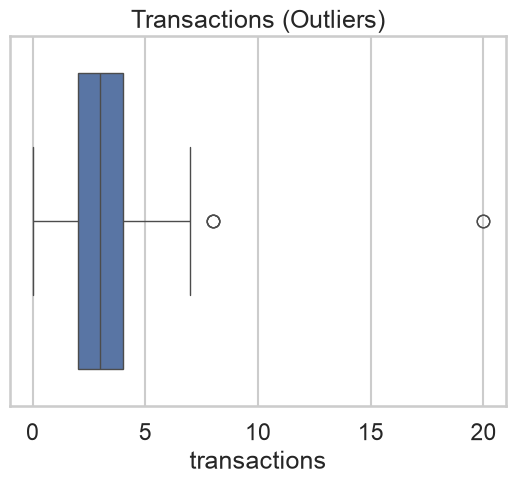

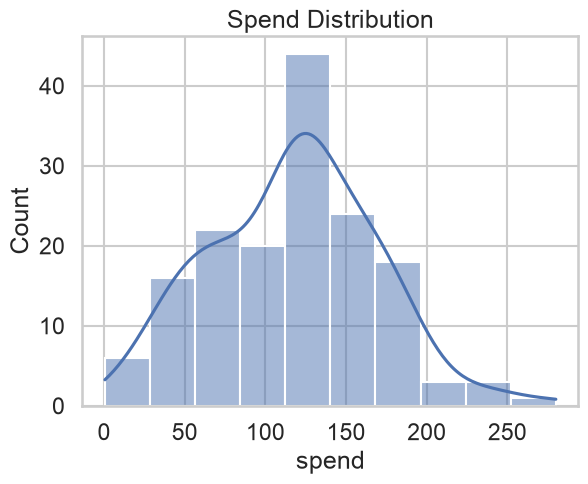

In [6]:
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

sns.histplot(df['spend'], kde=True)
plt.title('Spend Distribution')
plt.show()


## 4) Relationships — both are worked below; swap in your own columns

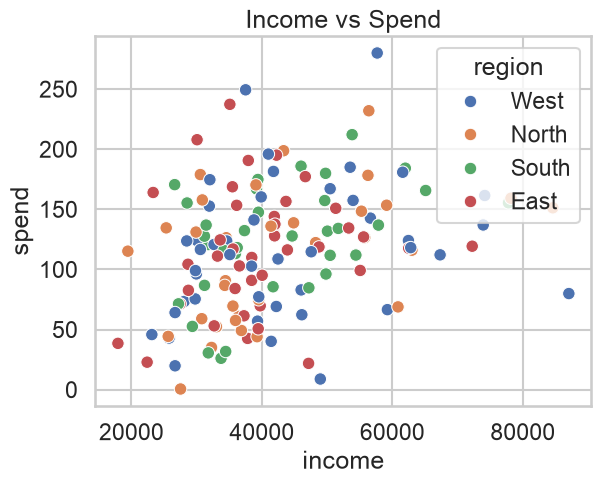

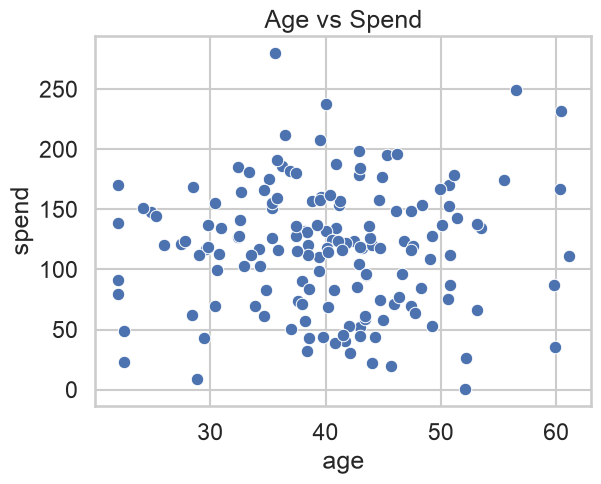

In [7]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

Date order monotonic: True
Missing calendar dates: 0


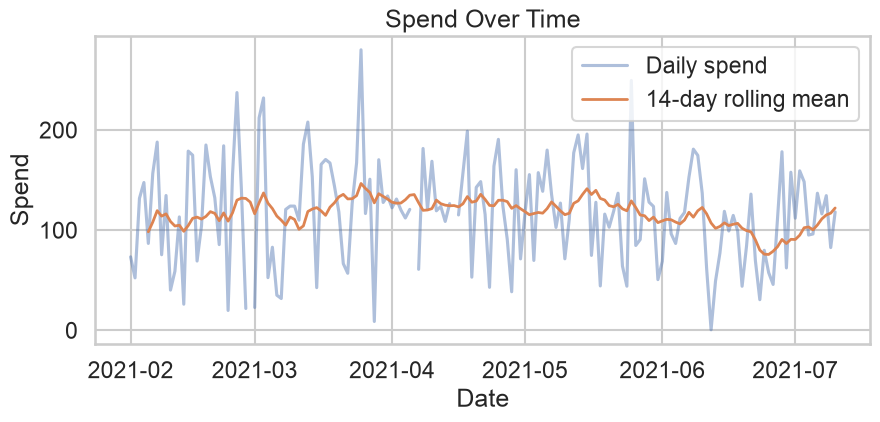

In [8]:
time_df = df.sort_values('date').set_index('date')
full_dates = pd.date_range(time_df.index.min(), time_df.index.max(), freq='D')
missing_dates = full_dates.difference(time_df.index)
print('Date order monotonic:', time_df.index.is_monotonic_increasing)
print('Missing calendar dates:', len(missing_dates))

plt.figure(figsize=(10, 4))
plt.plot(time_df.index, time_df['spend'], alpha=0.45, label='Daily spend')
plt.plot(
    time_df.index,
    time_df['spend'].rolling(14, min_periods=5).mean(),
    linewidth=2,
    label='14-day rolling mean',
)
plt.title('Spend Over Time')
plt.xlabel('Date')
plt.ylabel('Spend')
plt.legend()
plt.show()


## 5) (Optional) Correlation matrix

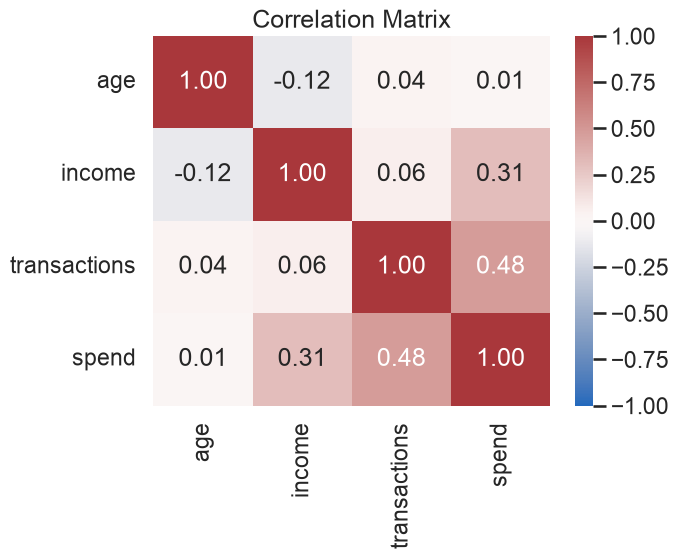

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [9]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [10]:
from src.eda import eda_summary

summary = eda_summary(df)


Shape: (160, 6)

Missing values:
date            0
region          0
age             0
income          5
transactions    0
spend           3
dtype: int64

Numeric summary:
              count          mean           std       min       25%       50%  \
age           160.0     40.018750      8.458676     22.00     34.70     40.15   
income        155.0  41983.866323  13262.457038  17928.80  32471.53  39332.52   
transactions  160.0      3.237500      2.585610      0.00      2.00      3.00   
spend         157.0    117.291592     51.768645      0.54     77.25    119.32   

                    75%       max  
age              44.925     61.10  
income        49697.690  87052.40  
transactions      4.000     20.00  
spend           153.340    280.05  

Categorical counts:
region {'West': 47, 'East': 42, 'South': 36, 'North': 35}


## 6) Insights & Assumptions

### Top 3 insights

1. Income is right-skewed, so the median is a safer typical-value summary than the mean and a log transform may be useful before modeling.
2. Transactions contain visible high outliers. They may represent unusually active customers rather than errors, so they should be retained in the raw data and tested with a sensitivity treatment.
3. Spend rises with income and transaction count, while the regional sample is reasonably distributed. The spend time series is noisy and its rolling mean does not show a strong deterministic trend or seasonal pattern in this short synthetic sample.

### Assumptions & risks

- The synthetic rows are treated as independent customer-day observations even though the date index could imply temporal dependence.
- Missing income and spend values are assumed to be accidental; if missingness is systematic, simple imputation could bias later models.
- Correlation does not establish causation, and the small number of injected outliers can materially affect summary statistics.

### Next steps before modeling

- Impute numeric missing values using training-set statistics only.
- Consider a log transform for income and robust treatment or flags for transaction outliers.
- Engineer spend-to-income, rolling spend, and regional encoding features while preserving date order to prevent leakage.
